## EDA

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"C:\projects_endtoend\loan_approval_prediction\loan_prediction.csv")

In [3]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.shape

(614, 13)

In [5]:
data.drop('Loan_ID',axis=1,inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


In [7]:
## duplicates

data.duplicated().sum()

0

In [8]:
## stats

data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
## missing values

data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

* columns Gender,Married,Dependents, Self Employed,LoanAmount, Loan_Amount_term, Credict_History has missing values 

## categotical vs numerical

In [10]:
## categorical

categorical = data.columns[data.dtypes=='object']
categorical

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [11]:
data.columns[data.dtypes=='object'].isnull().sum()

0

In [12]:
## numerical

numerical = data.columns[data.dtypes!='object']
numerical

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [13]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


* Loan_Status is the binary class target column 

* Property_area, Education and Dependents are ordinal columns of categorical features
* Gender, Married, Self_Employed, Credit_History, Loan Status are categorical features
* ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term are numerical fetaures

<Axes: xlabel='Loan_Status', ylabel='count'>

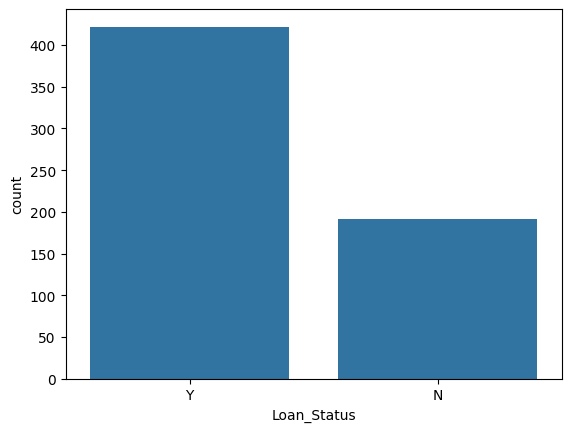

In [15]:
sns.countplot(data,x='Loan_Status')

### visulizing categorical features

In [16]:
gender_counts = data['Gender'].value_counts()
married_counts = data['Married'].value_counts()
selfemployed_counts = data['Self_Employed'].value_counts()
credit_counts = data['Credit_History'].value_counts()


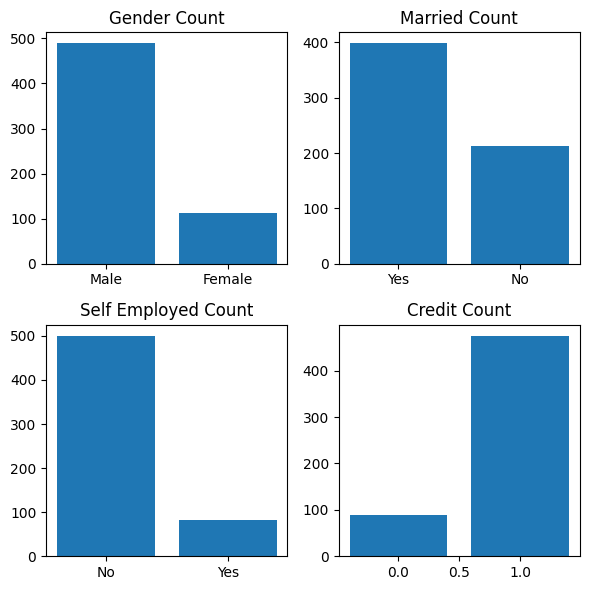

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(6,6))

# Plot Gender count
axs[0,0].bar(gender_counts.index, gender_counts.values)
axs[0,0].set_title('Gender Count')


# Plot Married count
axs[0,1].bar(married_counts.index, married_counts.values)
axs[0,1].set_title('Married Count')



# Plot swelf employed count
axs[1,0].bar(selfemployed_counts.index, selfemployed_counts.values)
axs[1,0].set_title('Self Employed Count')


## plot credit count
axs[1,1].bar(credit_counts.index, credit_counts.values)
axs[1,1].set_title('Credit Count')



# Adjust layout
plt.tight_layout()
plt.show()

### Insights:

* applicants count of male are more than female
* most of the applicants are married
* count of self employed is less
* most of the appilcants have cleared their debts

### visualizing ordinal columns

In [18]:
property_counts = data['Property_Area'].value_counts()
education_counts = data['Education'].value_counts()
dependents_counts = data['Dependents'].value_counts()

Text(0.5, 1.0, 'SProperty Count')

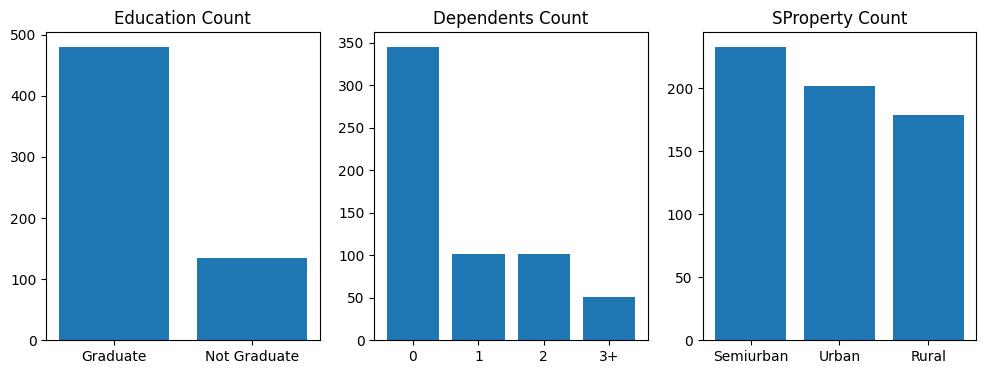

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(12,4))

# Plot education count
axs[0].bar(education_counts.index, education_counts.values)
axs[0].set_title('Education Count')


# Plot dependents count
axs[1].bar(dependents_counts.index, dependents_counts.values)
axs[1].set_title('Dependents Count')



# Plot property count
axs[2].bar(property_counts.index, property_counts.values)
axs[2].set_title('SProperty Count')


### Insights:

* Count of graduates are more than non-graduates
* most of the applicants don't have dependents
* most of the applicants are from semi-urban areas

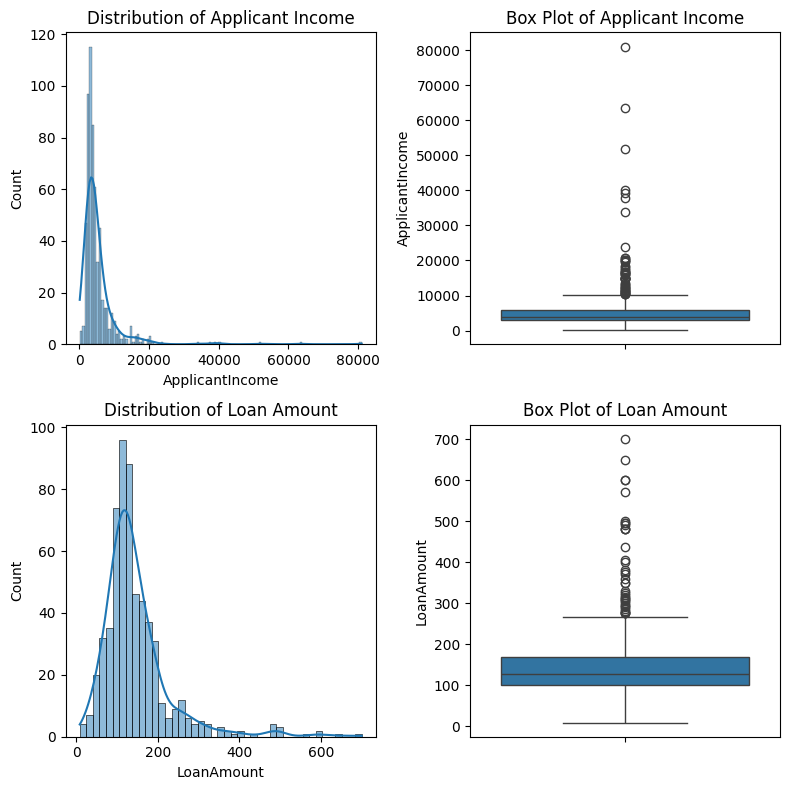

In [20]:
# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(8,8))

# Plot Applicant Income
sns.histplot(data['ApplicantIncome'], kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Distribution of Applicant Income')
sns.boxplot(data=data['ApplicantIncome'], ax=axs[0, 1])
axs[0, 1].set_title('Box Plot of Applicant Income')

# # Plot Coapplicant Income
# sns.histplot(data['CoapplicantIncome'], kde=True, ax=axs[1, 0])
# axs[1, 0].set_title('Distribution of Coapplicant Income')
# sns.boxplot(data=data['CoapplicantIncome'], ax=axs[1, 1])
# axs[1, 1].set_title('Box Plot of Coapplicant Income')

# Plot Loan Amount
sns.histplot(data['LoanAmount'], kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Distribution of Loan Amount')
sns.boxplot(data=data['LoanAmount'], ax=axs[1, 1])
axs[1, 1].set_title('Box Plot of Loan Amount')

# # Plot Loan Amount Term
# sns.histplot(data['Loan_Amount_Term'], kde=True, ax=axs[3, 0])
# axs[3, 0].set_title('Distribution of Loan Amount Term')
# sns.boxplot(data=data['Loan_Amount_Term'], ax=axs[3, 1])
# axs[3, 1].set_title('Box Plot of Loan Amount Term')

# Adjust layout
plt.tight_layout()
plt.show()

### Insights:

* Applicant income is not normally distributed

* Loan amout has lot of outliers

## Relationship b/w categorical and target variable

<Axes: xlabel='Gender', ylabel='count'>

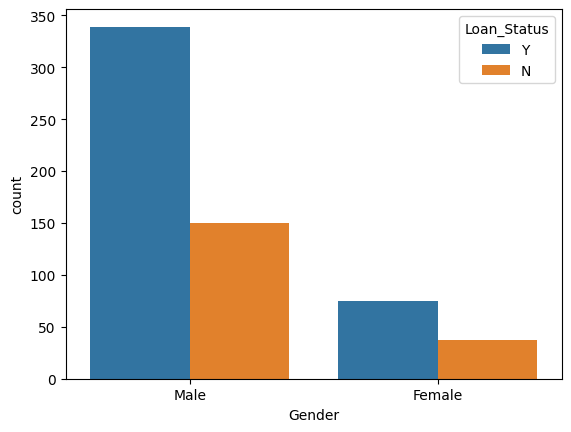

In [21]:
sns.countplot(data,x='Gender',hue='Loan_Status')

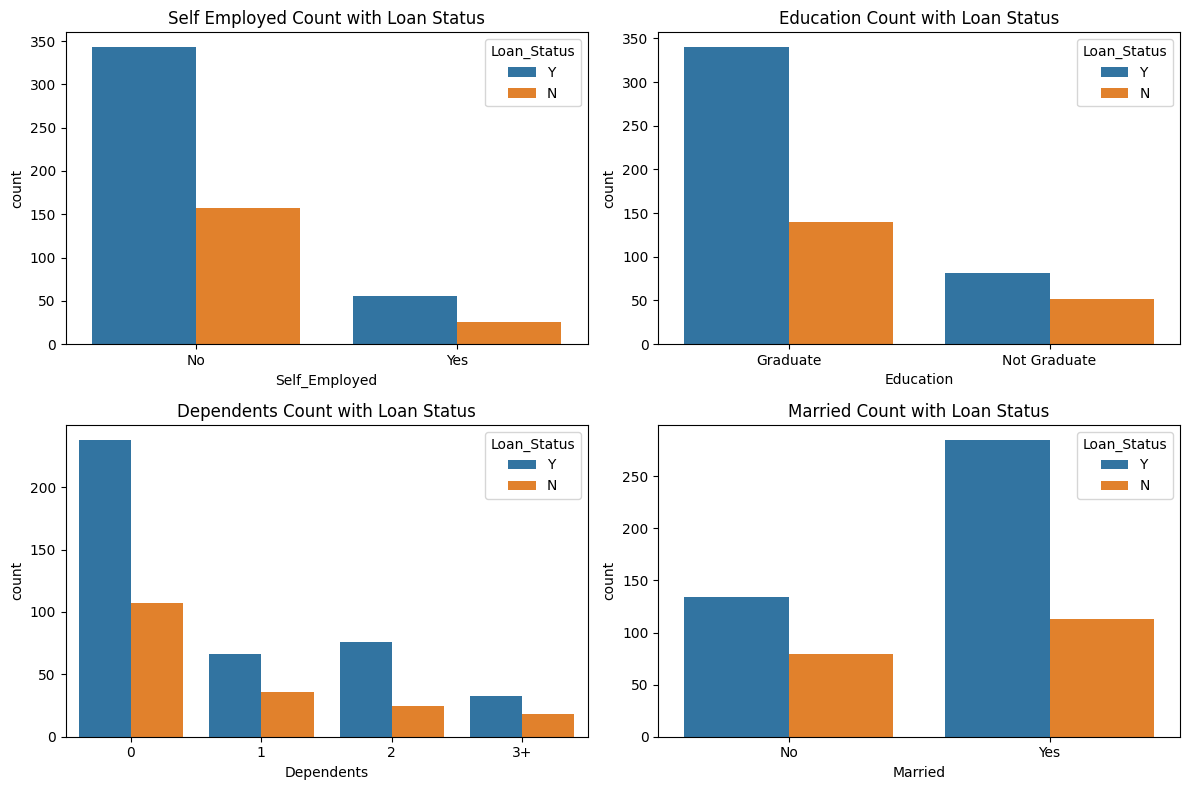

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

# Plot Self Employed count with hue=Loan_Status
sns.countplot(data=data, x='Self_Employed', hue='Loan_Status', ax=axs[0, 0])
axs[0, 0].set_title('Self Employed Count with Loan Status')

# Plot Education count with hue=Loan_Status
sns.countplot(data=data, x='Education', hue='Loan_Status', ax=axs[0, 1])
axs[0, 1].set_title('Education Count with Loan Status')

# Plot Dependents count with hue=Loan_Status
sns.countplot(data=data, x='Dependents', hue='Loan_Status', ax=axs[1, 0])
axs[1, 0].set_title('Dependents Count with Loan Status')

# Plot Married count with hue=Loan_Status
sns.countplot(data=data, x='Married', hue='Loan_Status', ax=axs[1, 1])
axs[1, 1].set_title('Married Count with Loan Status')

# Adjust layout
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Property area Count with Loan Status')

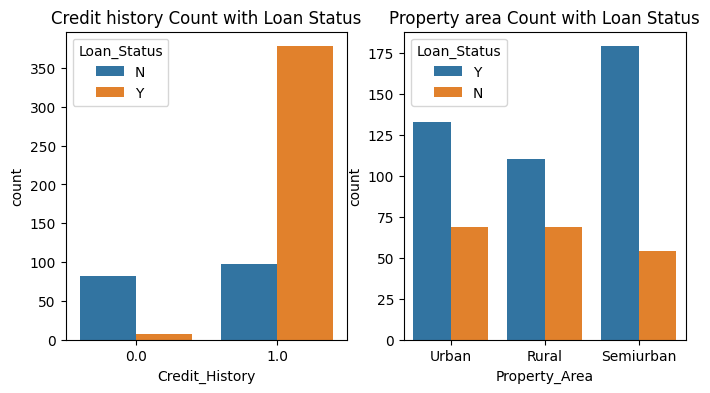

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(8,4))

# Plot Self Employed count with hue=Loan_Status
sns.countplot(data=data, x='Credit_History', hue='Loan_Status', ax=axs[0])
axs[0].set_title('Credit history Count with Loan Status')

# Plot Education count with hue=Loan_Status
sns.countplot(data=data, x='Property_Area', hue='Loan_Status', ax=axs[1])
axs[1].set_title('Property area Count with Loan Status')

## Handling missing values

In [24]:
data.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

* For numerical variables: imputation using mean or median
* For categorical variables: imputation using mode

In [25]:
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
data['Married'].fillna(data['Married'].mode()[0],inplace=True)
data['Dependents'].fillna(data['Dependents'].mode()[0],inplace=True)
data['Self_Employed'].fillna(data['Self_Employed'].mode()[0],inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mode()[0],inplace=True)

In [26]:
data['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

* since the distribution of loan amount is highly skewed, we can fill the missing values with median to handle outliers
* since the credit history is a binary column, we can fill the missing values with mode
* since the loan amount term is a discrete value and also the value of 360 is repeated the most, so mode is an appropriate metric to use

In [27]:
data['Credit_History'].fillna(data['Credit_History'].mode()[0],inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].median(),inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0],inplace=True)

In [28]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Handling outliers

* we have seen that loan amount and applicant income is right skewed, One way to remove the skewness is by doing the log transformation. 

* As we take the log transformation, it does not affect the smaller values much but reduces the larger values. So, we get a distribution similar to the normal distribution.

In [29]:
data['LoanAmount'] = np.log(data['LoanAmount']) 

<Axes: xlabel='LoanAmount', ylabel='Count'>

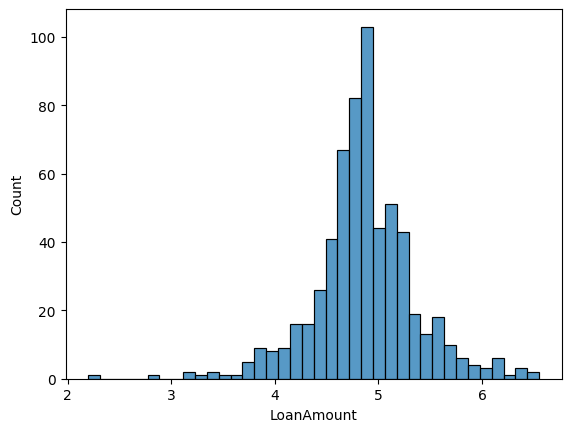

In [30]:
sns.histplot(data['LoanAmount'])

In [31]:
data['ApplicantIncome']=np.log(data['ApplicantIncome'])

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

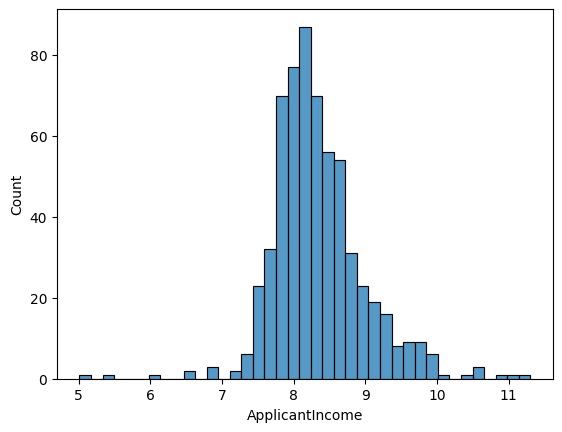

In [32]:
sns.histplot(data['ApplicantIncome'])

In [35]:
data.columns[data.dtypes=='object']

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [37]:
df_dummies = pd.get_dummies(data,columns=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'])


In [38]:
df_dummies.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,...,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_N,Loan_Status_Y
0,8.674026,0.0,4.852030,360.0,1.0,False,True,True,False,True,...,False,True,False,True,False,False,False,True,False,True
1,8.430109,1508.0,4.852030,360.0,1.0,False,True,False,True,False,...,False,True,False,True,False,True,False,False,True,False
2,8.006368,0.0,4.189655,360.0,1.0,False,True,False,True,True,...,False,True,False,False,True,False,False,True,False,True
3,7.856707,2358.0,4.787492,360.0,1.0,False,True,False,True,True,...,False,False,True,True,False,False,False,True,False,True
4,8.699515,0.0,4.948760,360.0,1.0,False,True,True,False,True,...,False,True,False,True,False,False,False,True,False,True


In [43]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,8.674026,0.0,4.852030,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,8.430109,1508.0,4.852030,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,8.006368,0.0,4.189655,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,7.856707,2358.0,4.787492,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,8.699515,0.0,4.948760,360.0,1.0,Urban,Y


In [47]:
data.columns[data.dtypes=='object']

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [49]:
print(data['Gender'].unique())
print(data['Married'].unique())
print(data['Dependents'].unique())
print(data['Education'].unique())
print(data['Self_Employed'].unique())
print(data['Property_Area'].unique())
print(data['Loan_Status'].unique())

['Male' 'Female']
['No' 'Yes']
['0' '1' '2' '3+']
['Graduate' 'Not Graduate']
['No' 'Yes']
['Urban' 'Rural' 'Semiurban']
['Y' 'N']


In [50]:
gender_map = {'Male':1,'Female':0}
married_map = {'Yes':1,'No':0}
depend_map = {'0':0,'1':1,'2':2,'3+':3}
educ_map = {'Graduate':1,'Not Graduate':0}
self_emp = {'Yes':1,'No':0}
property_map = {'Rural':0,'Urban':1,'Semiurban':2}
loan_map = {'Y':1,'N':0}


In [51]:
data['Gender'] = data['Gender'].map(gender_map)
data['Married'] = data['Married'].map(married_map)
data['Dependents'] = data['Dependents'].map(depend_map)
data['Education'] = data['Education'].map(educ_map)
data['Self_Employed'] = data['Self_Employed'].map(self_emp)
data['Property_Area'] = data['Property_Area'].map(property_map)
data['Loan_Status'] = data['Loan_Status'].map(loan_map)

In [52]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,8.674026,0.0,4.852030,360.0,1.0,1,1
1,1,1,1,1,0,8.430109,1508.0,4.852030,360.0,1.0,0,0
2,1,1,0,1,1,8.006368,0.0,4.189655,360.0,1.0,1,1
3,1,1,0,0,0,7.856707,2358.0,4.787492,360.0,1.0,1,1
4,1,0,0,1,0,8.699515,0.0,4.948760,360.0,1.0,1,1
